### **Necessary Libraries**

In [4]:
pip install plotly


   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.8 MB 621.1 kB/s eta 0:00:23
   - -------------------------------------- 0.5/14.8 MB 621.1 kB/s eta 0:00:23
   -- ------------------------------------- 0.8/14.8 MB 615.7 kB/s eta 0:00:23
   -- ------------------------------------- 0.8/14.8 MB 615.7 kB/s eta 0:00:23
   -- ------------------------------------- 1.0/14.8 MB 614.6 kB/s eta 0:00:23
   -- ------------------------------------- 1.0/14.8 MB 614.6 kB/s eta 0:00:23
   --- ------------------------------------ 1.3/14.8 MB 614.4 kB/s eta 0:00:22
   --- ------------------------------------ 1.3/14.8 MB 614.4 kB/s eta 0:00:22
   ---- ----------------------------------- 1.6/14.8 MB 611.1 kB/s eta 0:00:22
   ---- ----------------------------------- 1.6/14.8 MB 611.1 kB/s eta 0:00:22



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

### **Exploring The Datset**

In [ ]:
df=pd.read_excel("Coffee_Shop_Sales.xlsx")

In [161]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [5]:
num_duplicates = df.duplicated().sum()
print(f"Total number of duplicate rows in the dataset: {num_duplicates}")

Total number of duplicate rows in the dataset: 0


In [6]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


**Since The Data Seems Clean Let's Deep Dive Into The Analysis**

# **Customer and Sales Analysis**

### 1. What are the peak transaction times during the day, and how do they vary by store location?

In [163]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [164]:
unique_times = df['transaction_time'].nunique()
unique_times

25762

In [165]:
df["transaction_time"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 149116 entries, 0 to 149115
Series name: transaction_time
Non-Null Count   Dtype 
--------------   ----- 
149116 non-null  object
dtypes: object(1)
memory usage: 1.1+ MB


In [166]:
pd.to_timedelta(df['transaction_time'].astype(str))

0        0 days 07:06:11
1        0 days 07:08:56
2        0 days 07:14:04
3        0 days 07:20:24
4        0 days 07:22:41
               ...      
149111   0 days 20:18:41
149112   0 days 20:25:10
149113   0 days 20:31:34
149114   0 days 20:57:19
149115   0 days 20:57:19
Name: transaction_time, Length: 149116, dtype: timedelta64[ns]

In [167]:
df['transaction_date'] + pd.to_timedelta(df['transaction_time'].astype(str))

0        2023-01-01 07:06:11
1        2023-01-01 07:08:56
2        2023-01-01 07:14:04
3        2023-01-01 07:20:24
4        2023-01-01 07:22:41
                 ...        
149111   2023-06-30 20:18:41
149112   2023-06-30 20:25:10
149113   2023-06-30 20:31:34
149114   2023-06-30 20:57:19
149115   2023-06-30 20:57:19
Length: 149116, dtype: datetime64[ns]

In [168]:
df['transaction_datetime'] = df['transaction_date'] + pd.to_timedelta(df['transaction_time'].astype(str))

df['transaction_datetime']

0        2023-01-01 07:06:11
1        2023-01-01 07:08:56
2        2023-01-01 07:14:04
3        2023-01-01 07:20:24
4        2023-01-01 07:22:41
                 ...        
149111   2023-06-30 20:18:41
149112   2023-06-30 20:25:10
149113   2023-06-30 20:31:34
149114   2023-06-30 20:57:19
149115   2023-06-30 20:57:19
Name: transaction_datetime, Length: 149116, dtype: datetime64[ns]

In [169]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_datetime
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11


In [172]:
df['transaction_datetime'].dt.hour

0          7
1          7
2          7
3          7
4          7
          ..
149111    20
149112    20
149113    20
149114    20
149115    20
Name: transaction_datetime, Length: 149116, dtype: int32

In [173]:
# Combining date and time into a single datetime column
df['transaction_datetime'] = df['transaction_date'] + pd.to_timedelta(df['transaction_time'].astype(str))

# Extracting the hour from the new transaction_datetime column
df['transaction_hour'] = df['transaction_datetime'].dt.hour


In [174]:
df[['transaction_datetime','transaction_hour']]

,transaction_datetime,transaction_hour
0,2023-01-01 07:06:11,7
1,2023-01-01 07:08:56,7
2,2023-01-01 07:14:04,7
3,2023-01-01 07:20:24,7
4,2023-01-01 07:22:41,7
...,...,...
149111,2023-06-30 20:18:41,20
149112,2023-06-30 20:25:10,20
149113,2023-06-30 20:31:34,20
149114,2023-06-30 20:57:19,20


In [175]:
df.groupby(['store_location', 'transaction_hour'])['transaction_qty'].sum()

store_location   transaction_hour
Astoria          7                   5865
                 8                   6756
                 9                   7055
                 10                  7388
                 11                  4892
                 12                  4955
                 13                  4894
                 14                  4661
                 15                  4754
                 16                  4982
                 17                  4909
                 18                  4894
                 19                  4986
Hell's Kitchen   6                   2349
                 7                   4734
                 8                   9653
                 9                   9393
                 10                  9873
                 11                  5053
                 12                  3544
                 13                  3782
                 14                  3942
                 15                  3575


In [176]:
df.groupby(['store_location', 'transaction_hour'])['transaction_qty'].sum().reset_index(name='total_qty')

,store_location,transaction_hour,total_qty
0,Astoria,7,5865
1,Astoria,8,6756
2,Astoria,9,7055
3,Astoria,10,7388
4,Astoria,11,4892
5,Astoria,12,4955
6,Astoria,13,4894
7,Astoria,14,4661
8,Astoria,15,4754
9,Astoria,16,4982


In [177]:
# Aggregating transaction quantities by store location and transaction hour
peak_qty_hours = df.groupby(['store_location', 'transaction_hour'])['transaction_qty'].sum().reset_index(name='total_qty')

# Displaying the aggregated peak quantities
peak_qty_hours

,store_location,transaction_hour,total_qty
0,Astoria,7,5865
1,Astoria,8,6756
2,Astoria,9,7055
3,Astoria,10,7388
4,Astoria,11,4892
5,Astoria,12,4955
6,Astoria,13,4894
7,Astoria,14,4661
8,Astoria,15,4754
9,Astoria,16,4982


<BarContainer object of 43 artists>

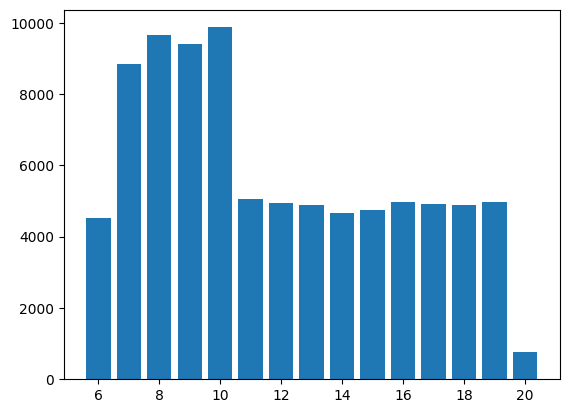

In [ ]:
## Matplotlib

plt.bar(peak_qty_hours["transaction_hour"],peak_qty_hours["total_qty"])

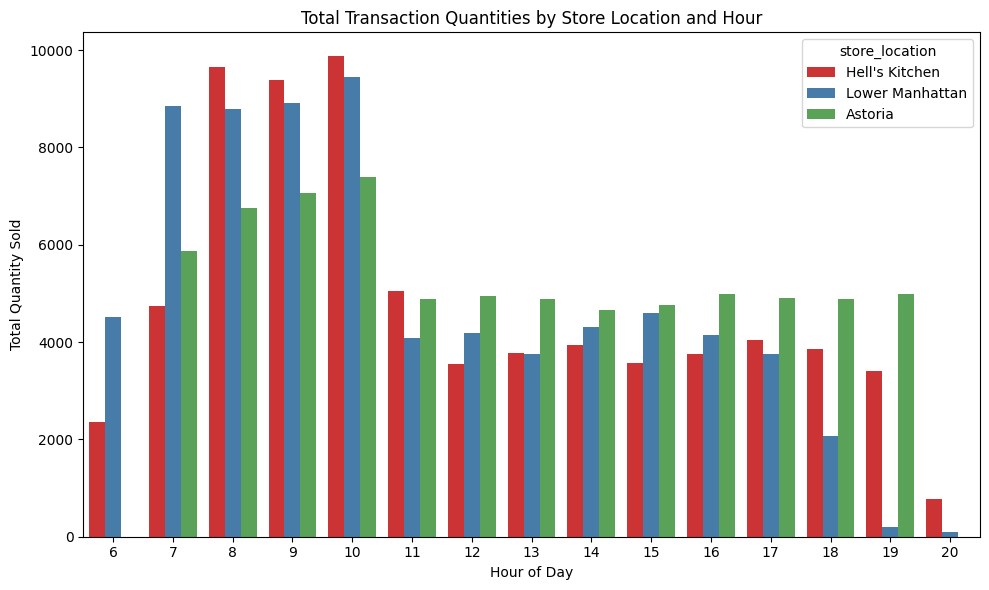

In [ ]:
## Seaborn
plt.figure(figsize=(10, 6))

sns.barplot(
    data=peak_qty_hours,
    x='transaction_hour',
    y='total_qty',
    hue='store_location',
   # palette='Set1'
)


plt.title('Total Transaction Quantities by Store Location and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Quantity Sold')
plt.tight_layout()
plt.show()



In [180]:
#plotly
fig_qty = px.bar(
    peak_qty_hours, 
    x='transaction_hour', 
    y='total_qty', 
    color='store_location', 
    title='<b>Total Transaction Quantities by Store Location and Hour</b>', 
    labels={'transaction_hour': 'Hour of Day', 'total_qty': 'Total Quantity Sold', 'store_location': 'Store Location'},
    text='total_qty', 
    color_discrete_sequence=px.colors.qualitative.Set1  # Apply Set1 color palette
)

fig_qty.show()

In [38]:
import plotly.express as px

fig = px.bar(
    peak_qty_hours,
    x='transaction_hour',
    y='total_qty',
    color='store_location',
    barmode='group',
    title='Total Transaction Quantities by Store Location and Hour',
    labels={
        'transaction_hour': 'Hour of Day',
        'total_qty': 'Total Quantity Sold',
        'store_location': 'Store Location'
    },
    text='total_qty'
)

fig.show()


### 2.Which store location has the highest total sales revenue ?

In [39]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_datetime,transaction_hour
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,7
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:08:56,7
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 07:14:04,7
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 07:20:24,7
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:22:41,7


In [181]:
# Adding a new column for total revenue
df['total_revenue'] = df['transaction_qty'] * df['unit_price']

In [182]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_datetime,transaction_hour,total_revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,7,6.0


In [41]:
# Grouping by store location to get total revenue
total_revenue_by_store = df.groupby('store_location')['total_revenue'].sum().reset_index().sort_values(by="total_revenue",ascending=False)
total_revenue_by_store

,store_location,total_revenue
1,Hell's Kitchen,236511.17
0,Astoria,232243.91
2,Lower Manhattan,230057.25


<Axes: xlabel='store_location', ylabel='total_revenue'>

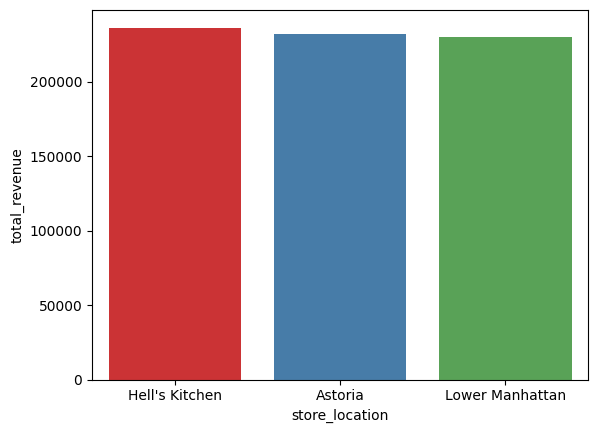

In [184]:
sns.barplot(total_revenue_by_store,x="store_location",y="total_revenue",hue='store_location',
    palette='Set1')

### 3. What are the best-selling product categories and types across different store locations?

In [44]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_datetime,transaction_hour,total_revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,7,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:08:56,7,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 07:14:04,7,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 07:20:24,7,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:22:41,7,6.2


In [185]:
## Top Selling Product Categories based on Location
category_summary = df.groupby(['store_location', 'product_category'])['transaction_qty'].sum().sort_values(ascending=False).reset_index()
category_summary 

,store_location,product_category,transaction_qty
0,Hell's Kitchen,Coffee,30220
1,Astoria,Coffee,29655
2,Lower Manhattan,Coffee,29375
3,Astoria,Tea,24048
4,Hell's Kitchen,Tea,22980
5,Lower Manhattan,Tea,22709
6,Lower Manhattan,Bakery,8040
7,Hell's Kitchen,Bakery,7678
8,Astoria,Bakery,7496
9,Astoria,Drinking Chocolate,6351


In [186]:
product_type_summary = df.groupby(['store_location', 'product_type'])['transaction_qty'].sum().reset_index()
product_type_summary = product_type_summary.sort_values(by='transaction_qty', ascending=False).groupby('store_location').head(10)
product_type_summary

,store_location,product_type,transaction_qty
4,Astoria,Brewed Chai tea,9306
29,Hell's Kitchen,Barista Espresso,9064
13,Astoria,Gourmet brewed coffee,8938
33,Hell's Kitchen,Brewed Chai tea,8755
71,Lower Manhattan,Gourmet brewed coffee,8563
58,Lower Manhattan,Barista Espresso,8534
42,Hell's Kitchen,Gourmet brewed coffee,8472
62,Lower Manhattan,Brewed Chai tea,8189
0,Astoria,Barista Espresso,7345
17,Astoria,Hot chocolate,6351


(<Figure size 640x480 with 1 Axes>, <Axes: >)

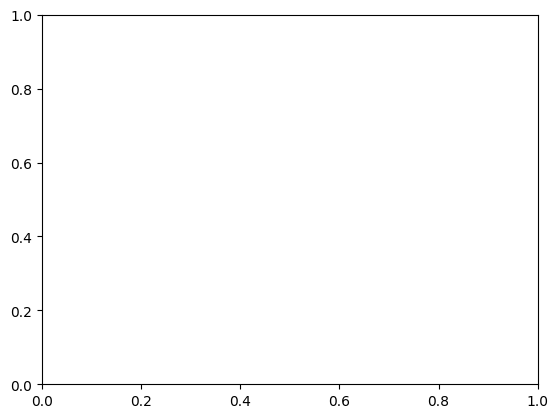

In [48]:
plt.subplots()

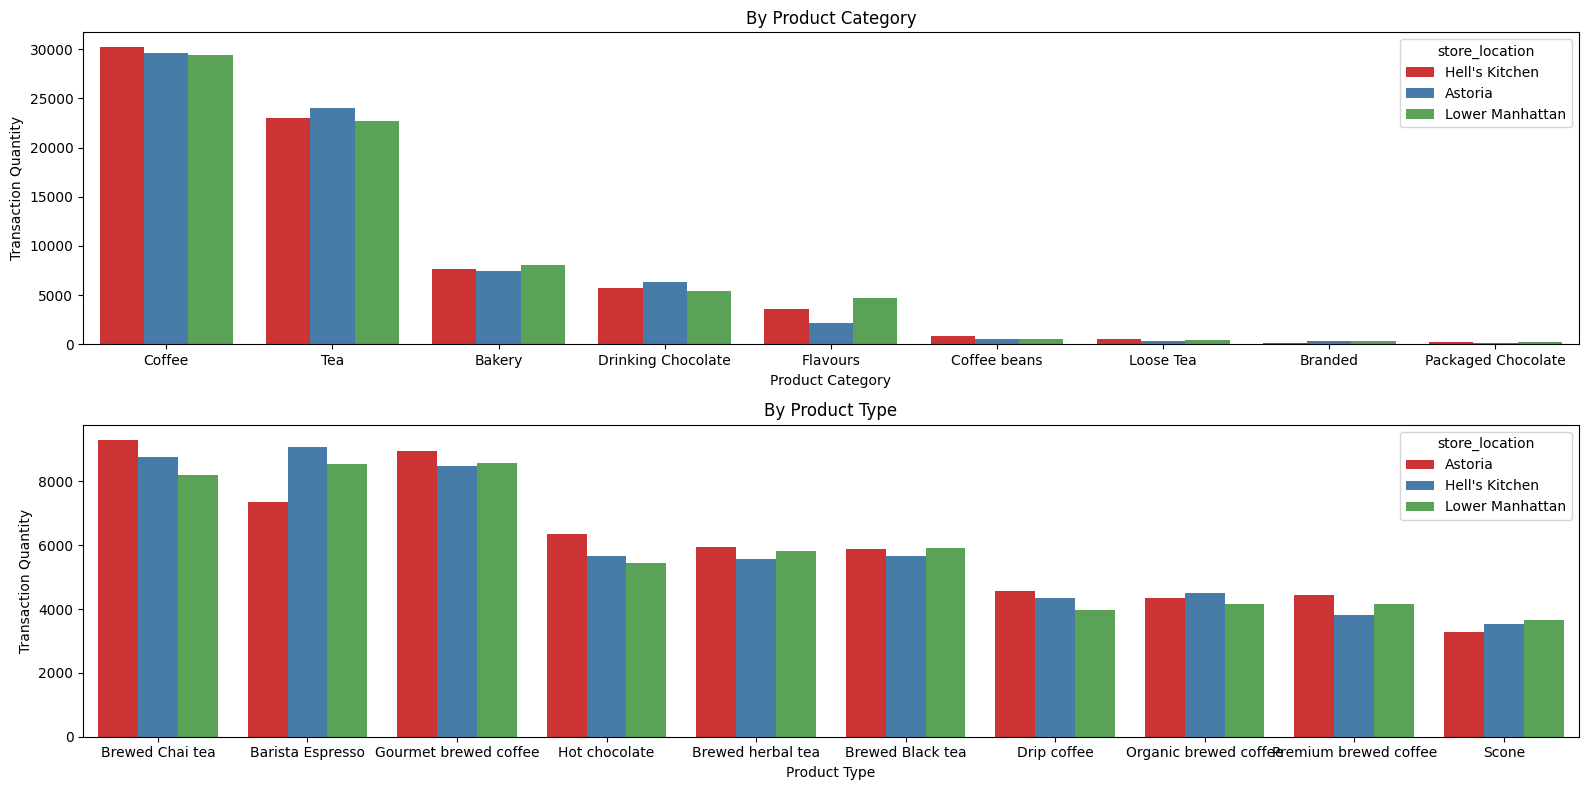

In [188]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

sns.barplot(
    data=category_summary,
    x="product_category",
    y="transaction_qty",
    hue="store_location",
    ax=axes[0],
    palette='Set1'
)
axes[0].set_title("By Product Category")
axes[0].set_xlabel("Product Category")
axes[0].set_ylabel("Transaction Quantity")

sns.barplot(
    data=product_type_summary,
    x="product_type",
    y="transaction_qty",
    hue="store_location",
    ax=axes[1],
    palette='Set1'
)
axes[1].set_title("By Product Type")
axes[1].set_xlabel("Product Type")
axes[1].set_ylabel("Transaction Quantity") 

plt.tight_layout()
plt.show()


### 4. How do these best-sellers align with the categories that contribute most to overall revenue?

In [65]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_datetime,transaction_hour,total_revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,7,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:08:56,7,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 07:14:04,7,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 07:20:24,7,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:22:41,7,6.2


In [ ]:
revenue_summary = df.groupby('product_category')['total_revenue'].sum().reset_index().sort_values(by='total_revenue',ascending=False)
revenue_summary

,product_category,total_revenue
2,Coffee,269952.45
8,Tea,196405.95
0,Bakery,82315.64
4,Drinking Chocolate,72416.00
3,Coffee beans,40085.25
1,Branded,13607.00
6,Loose Tea,11213.60
5,Flavours,8408.80
7,Packaged Chocolate,4407.64


In [69]:
# Group by store location and product category, then sum the total revenue
revenue_summary = (
    df.groupby(['store_location', 'product_category'])['total_revenue']
    .sum()
    .reset_index()
    .sort_values(by='total_revenue', ascending=False)
)

# Display the result
revenue_summary.head()

,store_location,product_category,total_revenue
11,Hell's Kitchen,Coffee,91222.65
2,Astoria,Coffee,89744.30
20,Lower Manhattan,Coffee,88985.50
8,Astoria,Tea,67839.90
17,Hell's Kitchen,Tea,64701.30


<Axes: xlabel='product_category', ylabel='total_revenue'>

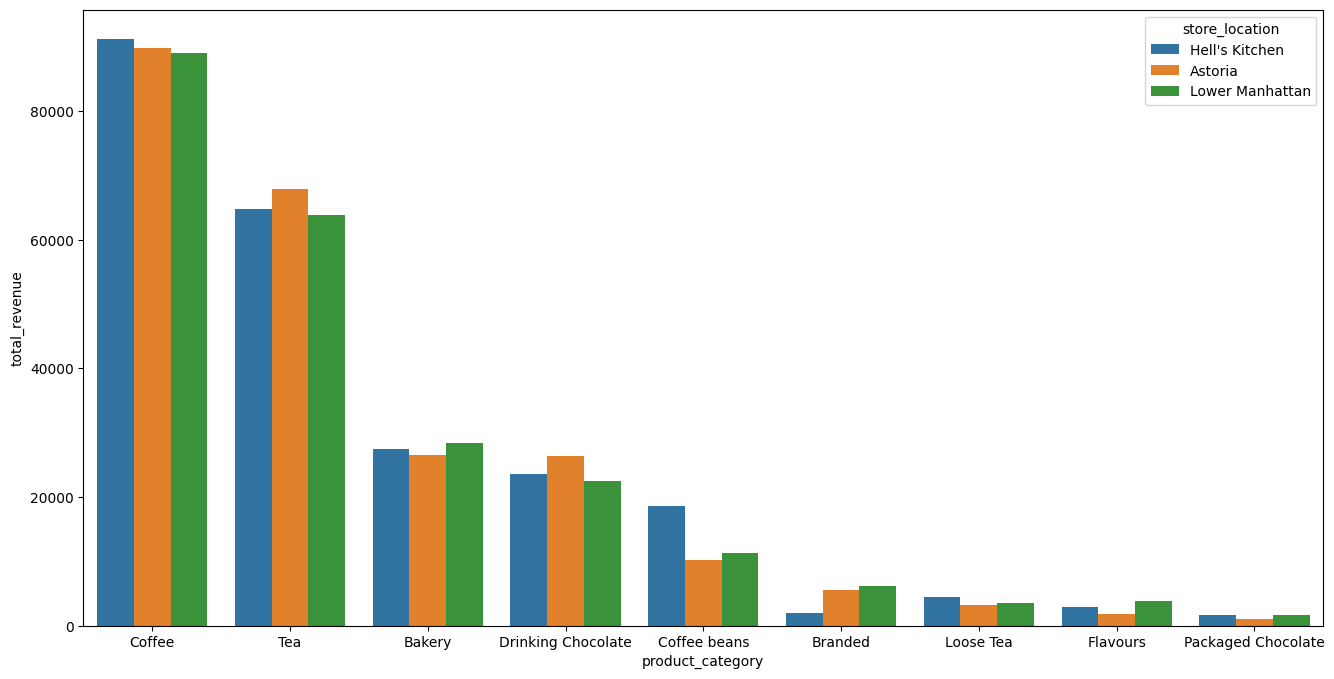

In [73]:
plt.figure(figsize=(16, 8))
sns.barplot(revenue_summary,x="product_category",y="total_revenue",hue="store_location")

### 5.How does the average unit price impact the total revenue and quantity sold for different product categories?

In [74]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_datetime,transaction_hour,total_revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,7,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:08:56,7,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 07:14:04,7,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 07:20:24,7,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:22:41,7,6.2


In [75]:
# Grouping the data by product category
summary_data = df.groupby('product_category').agg(
    average_unit_price=('unit_price', 'mean'),
    total_Revenue=('total_revenue', 'sum'),
    total_quantity_sold=('transaction_qty', 'sum')
).reset_index()
summary_data

,product_category,average_unit_price,total_Revenue,total_quantity_sold
0,Bakery,3.551682,82315.64,23214
1,Branded,17.720214,13607.00,776
2,Coffee,3.023646,269952.45,89250
3,Coffee beans,21.018397,40085.25,1828
4,Drinking Chocolate,4.148827,72416.00,17457
5,Flavours,0.800000,8408.80,10511
6,Loose Tea,9.267438,11213.60,1210
7,Packaged Chocolate,9.050595,4407.64,487
8,Tea,2.817121,196405.95,69737


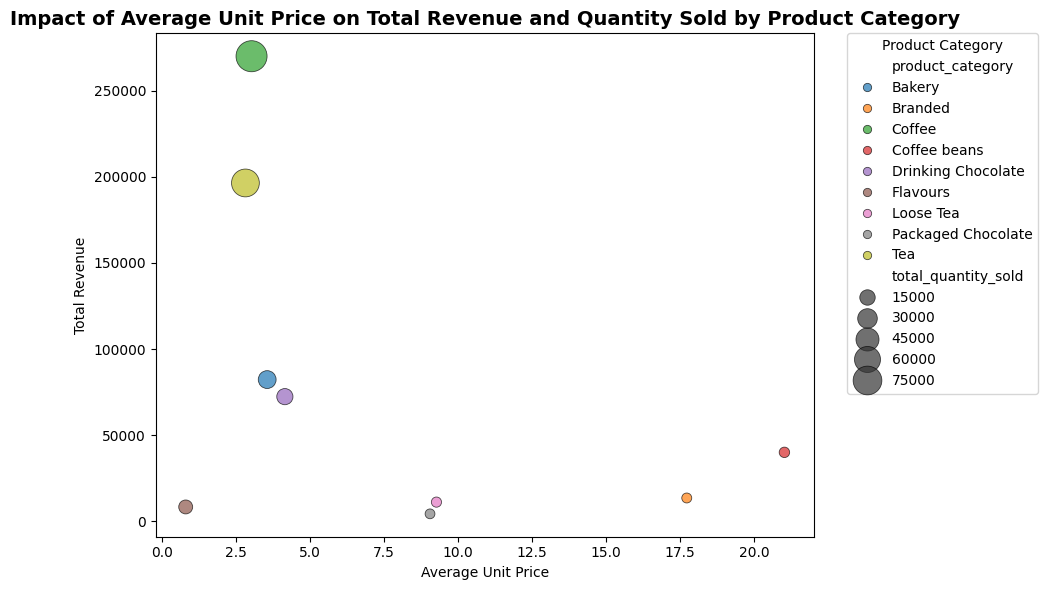

In [191]:
# Set up the figure
plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(
    data=summary_data,
    x='average_unit_price',
    y='total_Revenue',
    size='total_quantity_sold',
    sizes=(50, 500),  # adjust min/max marker size as needed
    hue='product_category',
    alpha=0.7,
    edgecolor="black"
)

# Labels and title
plt.title('Impact of Average Unit Price on Total Revenue and Quantity Sold by Product Category', fontsize=14, weight='bold')
plt.xlabel('Average Unit Price')
plt.ylabel('Total Revenue')

# Tweak legend
plt.legend(
    title='Product Category',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()


In [87]:
fig = px.scatter(
    summary_data,
    x='average_unit_price',
    y='total_Revenue',
    size='total_quantity_sold',
    color='product_category',
    hover_name='product_category',
    title='<b>Impact of Average Unit Price on Total Revenue and Quantity Sold by Product Category</b>',
    labels={
        'average_unit_price': 'Average Unit Price', 
        'total_sales': 'Total Sales'
    },
    color_discrete_sequence=px.colors.qualitative.Set1  

    
)


fig.update_layout(
    title_font=dict(size=20, family='Arial', color='black'),
    font=dict(size=12, family='Arial'),
    height=600,
    width=1200,
    plot_bgcolor='white',
    xaxis=dict(
        title='Average Unit Price',
        showgrid=True,
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Total Revenue',
        showgrid=True,
        gridcolor='lightgray'
    ),
    showlegend=True  # Keep the legend visible
)

# Adjust marker sizes to ensure visibility without overwhelming the chart
fig.update_traces(
    marker=dict(
        sizemode='area',
        sizeref=2.5*max(summary_data['total_quantity_sold'])/(60**2),  # Optimized for better balance
        sizemin=9,  # Ensure small points are visible without being too large
        line=dict(width=1.5, color='black')
    )
)

# Show the plot
fig.show()

### Question: What is the percentage distribution of total transaction quantities (transaction_qty) across different product_category types at the "Hell's Kitchen" store on January 1, 2023?

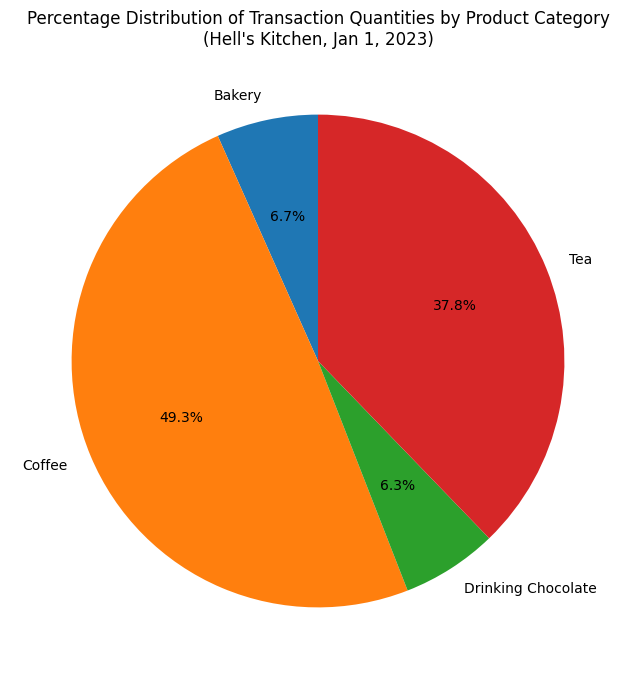

In [155]:
# Step 1: Filter the data
hells_kitchen = df[(df['transaction_date'] == '2023-01-01') & 
                   (df['store_location'] == "Hell's Kitchen")]

# Step 2: Group by product_category and sum transaction_qty
category_qty = hells_kitchen.groupby('product_category')['transaction_qty'].sum()

# Step 3: Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_qty, labels=category_qty.index, autopct='%1.1f%%', startangle=90)
plt.title("Percentage Distribution of Transaction Quantities by Product Category\n(Hell's Kitchen, Jan 1, 2023)")
plt.show()

### Question: What is the frequency distribution of unit_price values for all transactions at the "Lower Manhattan" store on January 1, 2023?

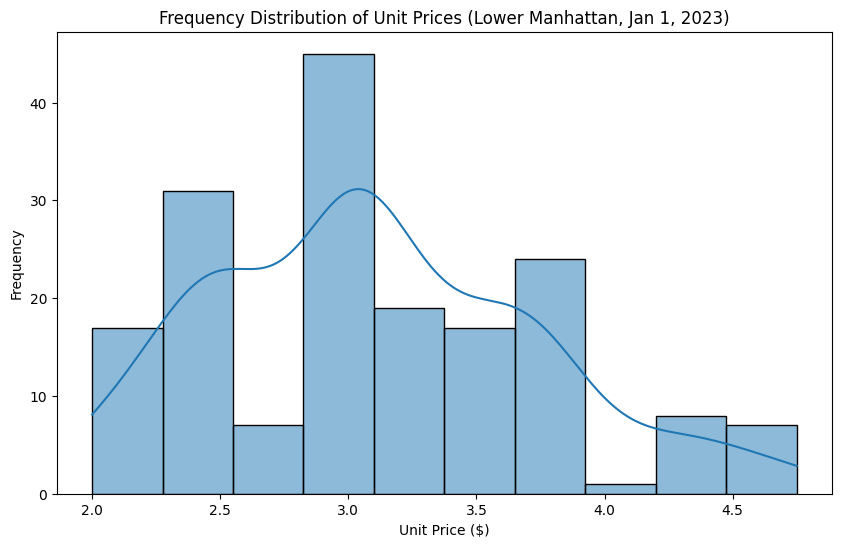

In [156]:
# Step 1: Filter the data
lm_transactions = df[(df['transaction_date'] == '2023-01-01') & 
                     (df['store_location'] == 'Lower Manhattan')]

# Step 2: Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=lm_transactions, x='unit_price', bins=10, kde=True)
plt.title('Frequency Distribution of Unit Prices (Lower Manhattan, Jan 1, 2023)')
plt.xlabel('Unit Price ($)')
plt.ylabel('Frequency')
plt.show()